In [9]:
!pip install tensorflow pandas numpy requests scikit-learn

In [10]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
from keras.models import Sequential
from keras.layers import LSTM, Dense
import requests
import datetime

In [27]:
import requests

def fetch_weather_data(api_key, city):
    url = f'http://api.openweathermap.org/data/2.5/weather?q={city}&appid={api_key}&units=metric'
    response = requests.get(url)
    data = response.json()

    weather_data = {
        'temp': data['main']['temp'],
        'rain_1h': data.get('rain', {}).get('1h', 0),
        'snow_1h': data.get('snow', {}).get('1h', 0),
        'clouds_all': data['clouds']['all']
    }

    return weather_data


In [31]:
def prepare_real_time_input(weather_data, hour_of_day, day_of_week, is_weekend, time_steps=10):
    # Time-related features (do not scale these)
    time_features = np.array([hour_of_day, day_of_week, is_weekend])

    # Weather features (scale these)
    weather_features = np.array([weather_data['temp'], weather_data['rain_1h'], 
                                 weather_data['snow_1h'], weather_data['clouds_all']])

    # Combine the time-related features with weather features (ensure consistent shape)
    input_features = np.concatenate([time_features, weather_features], axis=0).reshape(1, -1)

    # Scale only the weather features using the scaler (which was fitted only on the weather features)
    weather_scaled = scaler.transform(weather_features.reshape(1, -1))

    # Recreate the input features by combining time-related and scaled weather features
    scaled_input = np.concatenate([time_features, weather_scaled.flatten()], axis=0).reshape(1, -1)

    # Repeat the input data to create a sequence of length `time_steps`
    scaled_input_sequence = np.repeat(scaled_input, time_steps, axis=0).reshape(1, time_steps, scaled_input.shape[1])

    return scaled_input_sequence

In [32]:
def create_lstm_model(input_shape):
    model = Sequential()
    model.add(LSTM(units=50, return_sequences=True, input_shape=input_shape))
    model.add(LSTM(units=50, return_sequences=False))
    model.add(Dense(units=1))  # Output layer for regression task
    model.compile(optimizer='adam', loss='mean_squared_error')
    return model


In [33]:
data = pd.read_csv('Metro_Interstate_Traffic_Volume.csv')

In [34]:
data['date_time'] = pd.to_datetime(data['date_time'], format='%d-%m-%Y %H:%M')


In [35]:
data['hour_of_day'] = data['date_time'].dt.hour
data['day_of_week'] = data['date_time'].dt.dayofweek  # 0=Monday, 6=Sunday
data['is_weekend'] = data['day_of_week'].apply(lambda x: 1 if x >= 5 else 0)

In [36]:
features = data[['hour_of_day', 'day_of_week', 'is_weekend', 'temp', 'rain_1h', 'snow_1h', 'clouds_all']].values
labels = data['traffic_volume'].values

In [37]:
train_size = int(len(features) * 0.8)
X_train, X_test = features[:train_size], features[train_size:]
y_train, y_test = labels[:train_size], labels[train_size:]

In [38]:
scaler = MinMaxScaler()
X_train_weather = X_train[:, 3:]  # Extract weather features (temp, rain, snow, clouds)
scaler.fit(X_train_weather)


,feature_range,"(0, ...)"
,copy,True
,clip,False


In [40]:
X_train_weather_scaled = scaler.transform(X_train_weather)
X_train_scaled = np.concatenate([X_train[:, :3], X_train_weather_scaled], axis=1)

In [41]:
time_steps = 10  # Number of time steps in the input sequence
X_train_scaled = X_train_scaled.reshape(X_train_scaled.shape[0], 1, X_train_scaled.shape[1])

In [42]:
model = create_lstm_model(X_train_scaled.shape[1:])
model.fit(X_train_scaled, y_train, epochs=10, batch_size=32)

C:\Users\shahz\anaconda3\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/10
1206/1206 ━━━━━━━━━━━━━━━━━━━━ 11s 4ms/step - loss: 14384521.0000
Epoch 2/10
1206/1206 ━━━━━━━━━━━━━━━━━━━━ 6s 5ms/step - loss: 14073091.0000
Epoch 3/10
1206/1206 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - loss: 13778589.0000
Epoch 4/10
1206/1206 ━━━━━━━━━━━━━━━━━━━━ 11s 5ms/step - loss: 13490157.0000
Epoch 5/10
1206/1206 ━━━━━━━━━━━━━━━━━━━━ 9s 4ms/step - loss: 13206505.0000
Epoch 6/10
1206/1206 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - loss: 12927463.0000
Epoch 7/10
1206/1206 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - loss: 12653021.0000
Epoch 8/10
1206/1206 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - loss: 12382846.0000
Epoch 9/10
1206/1206 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - loss: 12116886.0000
Epoch 10/10
1206/1206 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - loss: 11855412.0000


In [43]:
api_key = 'd165ab6002938d8c5bb06cd0b3aa8973'  # Replace with your actual API key
city = 'New York'
weather_data = fetch_weather_data(api_key, city)

In [44]:
real_time_data = prepare_real_time_input(weather_data, hour_of_day=12, day_of_week=2, is_weekend=0)
real_time_prediction = model.predict(real_time_data)
print(f"Predicted Traffic Volume: {real_time_prediction[0][0]}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 538ms/step
Predicted Traffic Volume: 614.0482788085938


In [45]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import matplotlib.pyplot

In [46]:
X_test_weather = X_test[:, 3:]
X_test_weather_scaled = scaler.transform(X_test_weather)
X_test_scaled = np.concatenate([X_test[:, :3], X_test_weather_scaled], axis=1)
X_test_scaled = X_test_scaled.reshape(X_test_scaled.shape[0], 1, X_test_scaled.shape[1])

In [47]:
y_pred = model.predict(X_test_scaled)

302/302 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step


302/302 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
Mean Absolute Error: 2808.88623046875
Mean Squared Error: 11599919.0
Root Mean Squared Error: 3405.865381955077


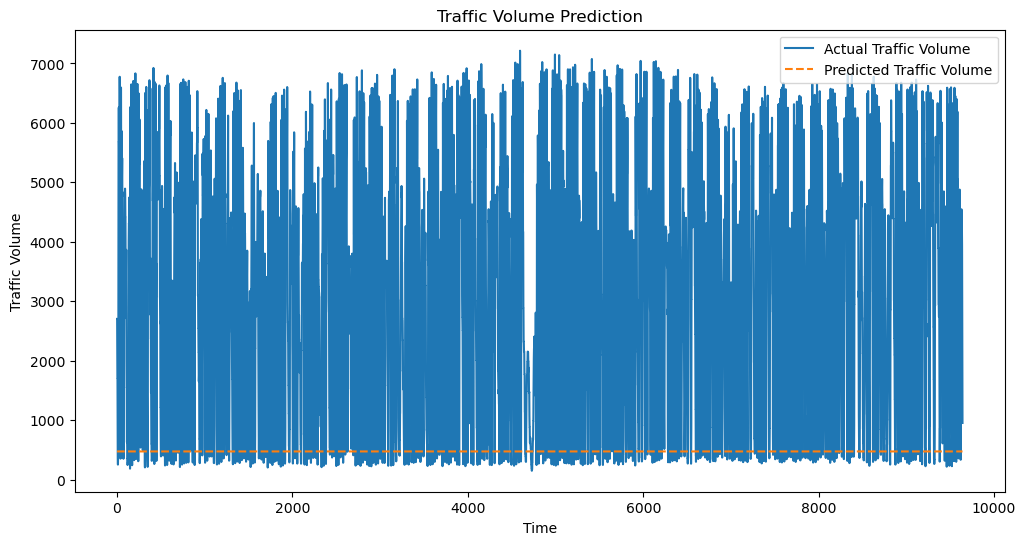

In [54]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import matplotlib.pyplot as plt

# Scale the test data
X_test_weather = X_test[:, 3:]
X_test_weather_scaled = scaler.transform(X_test_weather)
X_test_scaled = np.concatenate([X_test[:, :3], X_test_weather_scaled], axis=1)
X_test_scaled = X_test_scaled.reshape(X_test_scaled.shape[0], 1, X_test_scaled.shape[1])

# Predict on the test set
y_pred = model.predict(X_test_scaled)

# Calculate MAE, MSE, RMSE
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)

print(f"Mean Absolute Error: {mae}")
print(f"Mean Squared Error: {mse}")
print(f"Root Mean Squared Error: {rmse}")

# Visualize predictions
plt.figure(figsize=(12, 6))
plt.plot(y_test, label='Actual Traffic Volume')
plt.plot(y_pred, label='Predicted Traffic Volume', linestyle='--')
plt.legend()
plt.title("Traffic Volume Prediction")
plt.xlabel("Time")
plt.ylabel("Traffic Volume")
plt.show()

In [57]:
model.save('traffic_volume_predictor.h5')

In [59]:
from keras.models import load_model
model = load_model('traffic_volume_predictor.h5')

In [58]:
import logging
import datetime
import numpy as np
import pandas as pd
from sklearn.metrics import mean_absolute_error, mean_squared_error

# Set up logging to both console and file
logging.basicConfig(
    level=logging.INFO,
    format='%(asctime)s - %(levelname)s - %(message)s',
    handlers=[
        logging.FileHandler('model_performance.log'),  # File handler
        logging.StreamHandler()  # Console handler
    ]
)

# Log a test message
logging.info("Logging started successfully.")

# Function to log performance metrics
def log_performance(actual, predicted):
    mae = mean_absolute_error(actual, predicted)
    mse = mean_squared_error(actual, predicted)
    rmse = np.sqrt(mse)
    logging.info(f"MAE: {mae}, MSE: {mse}, RMSE: {rmse}, Time: {datetime.datetime.now()}")

# Placeholder for data preprocessing and model creation
def preprocess_data(data):
    # Assuming 'traffic_volume' is the target and rest are features
    features = data.drop(['traffic_volume'], axis=1).values  # Drop target column
    labels = data['traffic_volume'].values  # Target column
    return features, labels

def scale_data(data):
    from sklearn.preprocessing import StandardScaler
    scaler = StandardScaler()
    return scaler.fit_transform(data)

def create_lstm_model(input_shape):
    from keras.models import Sequential
    from keras.layers import LSTM, Dense

    model = Sequential()
    model.add(LSTM(units=50, return_sequences=False, input_shape=input_shape))
    model.add(Dense(units=1))  # Output layer for regression
    model.compile(optimizer='adam', loss='mean_squared_error')
    return model

# Function to retrain the model
def retrain_model():
    # Load new data
    new_data = pd.read_csv('Metro_Interstate_Traffic_Volume.csv')  # Replace with the path to the fresh data
    
    # Process the data (same preprocessing steps as before)
    features, labels = preprocess_data(new_data)
    
    # Normalize the features
    scaler = scale_data(features)
    
    # Reshape data for LSTM (assuming that data needs to be 3D for LSTM)
    features_scaled = scaler.reshape(features.shape[0], 1, features.shape[1])
    
    # Retrain the model
    model = create_lstm_model(features_scaled.shape[1:])
    model.fit(features_scaled, labels, epochs=10, batch_size=32)
    
    # Save the retrained model
    model.save('traffic_volume_predictor_retrained.h5')
    print("Model retrained successfully!")

# Log performance metrics
log_performance(y_test, y_pred)

# Read and print the contents of the log file to verify
try:
    with open('model_performance.log', 'r') as file:
        log_contents = file.read()
        print(log_contents)  # Print log contents to the console
except FileNotFoundError:
    print("Log file not found. Please check if logging is set up correctly.")


2024-12-25 20:05:54,965 - INFO - Logging started successfully.
2024-12-25 20:06:50,462 - WARNING - You are saving your model as an HDF5 file via `model.save()` or `keras.saving.save_model(model)`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')` or `keras.saving.save_model(model, 'my_model.keras')`. 
2024-12-25 20:06:53,399 - WARNING - Compiled the loaded model, but the compiled metrics have yet to be built. `model.compile_metrics` will be empty until you train or evaluate the model.
2024-12-25 20:07:02,860 - INFO - Logging started successfully.
2024-12-25 20:07:02,863 - INFO - MAE: 2809.1115852817315, MSE: 11601540.34948954, RMSE: 3406.1033967702065, Time: 2024-12-25 20:07:02.863210
2026-01-07 04:58:18,836 - INFO - Logging started successfully.
2026-01-07 05:34:35,820 - WARNING - 5 out of the last 306 calls to <function TensorFlowTrainer.make_predict_function.<locals>.one_step_on_data_distributed at 0x000001

In [61]:
#  Traditional Machine Learning Models (Baseline Comparison)

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error

# Prepare 2D data (NOT LSTM data)
X_ml = data[['hour_of_day', 'day_of_week', 'is_weekend',
             'temp', 'rain_1h', 'snow_1h', 'clouds_all']]
y_ml = data['traffic_volume']

# Train-test split
split = int(len(X_ml) * 0.8)
X_train_ml, X_test_ml = X_ml[:split], X_ml[split:]
y_train_ml, y_test_ml = y_ml[:split], y_ml[split:]

# Scale weather features
scaler_ml = MinMaxScaler()
X_train_ml.iloc[:, 3:] = scaler_ml.fit_transform(X_train_ml.iloc[:, 3:])
X_test_ml.iloc[:, 3:] = scaler_ml.transform(X_test_ml.iloc[:, 3:])


C:\Users\shahz\AppData\Local\Temp\ipykernel_7904\1760423241.py:20: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[0.4  0.75 0.9  ... 0.9  0.9  0.9 ]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  X_train_ml.iloc[:, 3:] = scaler_ml.fit_transform(X_train_ml.iloc[:, 3:])
C:\Users\shahz\AppData\Local\Temp\ipykernel_7904\1760423241.py:21: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[0.9 0.9 0.9 ... 0.9 0.9 0.9]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  X_test_ml.iloc[:, 3:] = scaler_ml.transform(X_test_ml.iloc[:, 3:])


In [62]:
lr = LinearRegression()
lr.fit(X_train_ml, y_train_ml)

lr_preds = lr.predict(X_test_ml)
print("Linear Regression MSE:", mean_squared_error(y_test_ml, lr_preds))


Linear Regression MSE: 3152079.1671467326


In [63]:
dt_reg = DecisionTreeRegressor(max_depth=10)
dt_reg.fit(X_train_ml, y_train_ml)

dt_preds = dt_reg.predict(X_test_ml)
print("Decision Tree Regression MSE:", mean_squared_error(y_test_ml, dt_preds))


Decision Tree Regression MSE: 299060.8378889808


In [64]:
rf_reg = RandomForestRegressor(n_estimators=100, random_state=42)
rf_reg.fit(X_train_ml, y_train_ml)

rf_preds = rf_reg.predict(X_test_ml)
print("Random Forest Regression MSE:", mean_squared_error(y_test_ml, rf_preds))


Random Forest Regression MSE: 330494.5483210678


In [65]:
#  Traffic Level Classification Models
# Create traffic level classes
data['traffic_level'] = pd.cut(
    data['traffic_volume'],
    bins=[0, 2000, 4000, 7000],
    labels=[0, 1, 2]
)

X_cls = data[['hour_of_day', 'day_of_week', 'is_weekend',
              'temp', 'rain_1h', 'snow_1h', 'clouds_all']]
y_cls = data['traffic_level']

split = int(len(X_cls) * 0.8)
X_train_c, X_test_c = X_cls[:split], X_cls[split:]
y_train_c, y_test_c = y_cls[:split], y_cls[split:]

X_train_c.iloc[:, 3:] = scaler_ml.fit_transform(X_train_c.iloc[:, 3:])
X_test_c.iloc[:, 3:] = scaler_ml.transform(X_test_c.iloc[:, 3:])


C:\Users\shahz\AppData\Local\Temp\ipykernel_7904\1088427637.py:17: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[0.4  0.75 0.9  ... 0.9  0.9  0.9 ]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  X_train_c.iloc[:, 3:] = scaler_ml.fit_transform(X_train_c.iloc[:, 3:])
C:\Users\shahz\AppData\Local\Temp\ipykernel_7904\1088427637.py:18: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[0.9 0.9 0.9 ... 0.9 0.9 0.9]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  X_test_c.iloc[:, 3:] = scaler_ml.transform(X_test_c.iloc[:, 3:])


In [73]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import MinMaxScaler

# Create Traffic Level Classes 
data['traffic_level'] = pd.cut(
    data['traffic_volume'],
    bins=[0, 2000, 4000, 7000],
    labels=[0, 1, 2],
    include_lowest=True
)

#  DROP NaNs FIRST (CRITICAL FIX)
data = data.dropna(subset=['traffic_level'])

#  NOW convert to int
data['traffic_level'] = data['traffic_level'].astype(int)

#  Prepare Classification Data 
X_cls = data[['hour_of_day', 'day_of_week', 'is_weekend',
              'temp', 'rain_1h', 'snow_1h', 'clouds_all']]
y_cls = data['traffic_level']

# Ensure no NaNs anywhere
X_cls = X_cls.fillna(0)
y_cls = y_cls.fillna(0)

split = int(len(X_cls) * 0.8)
X_train_c, X_test_c = X_cls[:split], X_cls[split:]
y_train_c, y_test_c = y_cls[:split], y_cls[split:]

# Scale weather features only 
scaler_cls = MinMaxScaler()
X_train_c.iloc[:, 3:] = scaler_cls.fit_transform(X_train_c.iloc[:, 3:])
X_test_c.iloc[:, 3:] = scaler_cls.transform(X_test_c.iloc[:, 3:])

# ---------- Step 7: Logistic Regression ----------
log_reg = LogisticRegression(
    max_iter=3000,
    solver='lbfgs',
    multi_class='auto'
)

log_reg.fit(X_train_c, y_train_c)

# ---------- Step 8: Predict & Evaluate ----------
log_preds = log_reg.predict(X_test_c)
accuracy = accuracy_score(y_test_c, log_preds)

print(" Logistic Regression Accuracy:", accuracy)


C:\Users\shahz\AppData\Local\Temp\ipykernel_7904\1992935588.py:39: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[0.4  0.75 0.9  ... 0.9  0.9  0.9 ]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  X_train_c.iloc[:, 3:] = scaler_cls.fit_transform(X_train_c.iloc[:, 3:])
C:\Users\shahz\AppData\Local\Temp\ipykernel_7904\1992935588.py:40: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[0.9 0.9 0.9 ... 0.9 0.9 0.9]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  X_test_c.iloc[:, 3:] = scaler_cls.transform(X_test_c.iloc[:, 3:])
C:\Users\shahz\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:1272: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. From then on, it will always use 'multinomial'. Leave it to its default valu

✅ Logistic Regression Accuracy: 0.6735901962820646
